# 05 — Analysis: RQ1 and RQ2 (P4)

Reads the P4 grid (`results/v3/synthetic/p4/grid.parquet`, Qwen2.5-7B-Instruct) and answers:
- **RQ1:** does in-context learning degrade under covariate shift, spurious reversal and concept shift (flipped names)?
- **RQ2:** do different selection strategies win under different shift types?

Every number is a mean over tasks of the per-task mean over demonstration seeds.
- **AUROC** ranks the queries by the calibrated p1 within a cell, with no threshold. It is the confirmatory statistic.
- **BA** is calibrated balanced accuracy, which equals accuracy on the 10/10 query sets. It is shown alongside.

The confirmatory tests are the frozen contrast family (`CONTRASTS` in `src/evaluation/analysis.py`, fixed before P4): hierarchical bootstrap, one-sided, Holm-adjusted.
Everything else is descriptive.

**Why AUROC and not BA** (the user's decision; `hiccups/15`): for plain random demonstrations, calibration with the content-free query often left all 20 queries of a cell on one side of the threshold.
That pins BA at 0.5 and hides shifts. Section 5 shows how often it happens.
The notebook runs on partial results; cells that need a missing part say so.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.utils.config import load_config, resolve_path  # first src import: sets the thread and MPS settings

config = load_config()

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.suites import load_suite
from src.evaluation.analysis import CONTRASTS, cell_metrics, prior_agreement, run_contrasts, summary_table

RESULTS = resolve_path(config.paths.results)
grid = pd.read_parquet(RESULTS / "p4" / "grid.parquet")
manifest = load_suite("eval", config)
sigma = {t["task_id"]: t["spurious_direction"] for t in manifest["tasks"]}
cells = cell_metrics(grid)
cells["spurious_direction"] = cells["task_id"].map(sigma)
print(f"{grid.unit_key.nunique()} units, {len(grid)} rows; namings {sorted(grid.naming.unique())}; "
      f"strategies {sorted(grid.strategy.unique())}")
print("median label mass:", round(float(cells['label_mass'].median()), 3))

482 units, 28920 rows; namings ['abstract', 'aligned']; strategies ['counter_spurious', 'feature_range', 'label_diversity', 'random', 'rule_diversity', 'similarity', 'zero_shot']
median label mass: 1.0


## 1. RQ1: does ICL degrade under shift?

Plain random demonstrations and zero-shot, by environment and naming.
The ID-minus-OOD gap of a query-agnostic strategy compares queries answered with the same prompt.

In [2]:
gold = cells[cells.label_mode == "gold"]
for value in ("ba", "auroc"):
    t = summary_table(gold[gold.strategy.isin(["zero_shot", "random", "label_diversity"])], value)
    print(value.upper()); display(t.round(3))

BA


naming           abstract                            aligned       \
env             covariate     id spurious_reversal covariate   id   
strategy                                                            
label_diversity     0.558  0.541             0.508       NaN  NaN   
random              0.538  0.544             0.508       0.5  0.5   
zero_shot           0.533  0.490             0.481       0.6  0.6   

naming                             
env             spurious_reversal  
strategy                           
label_diversity               NaN  
random                       0.55  
zero_shot                    0.65

AUROC


naming           abstract                            aligned        \
env             covariate     id spurious_reversal covariate    id   
strategy                                                             
label_diversity     0.652  0.589             0.519       NaN   NaN   
random              0.580  0.606             0.489      0.72  0.72   
zero_shot           0.530  0.492             0.493      0.77  0.62   

naming                             
env             spurious_reversal  
strategy                           
label_diversity               NaN  
random                       0.59  
zero_shot                    0.82

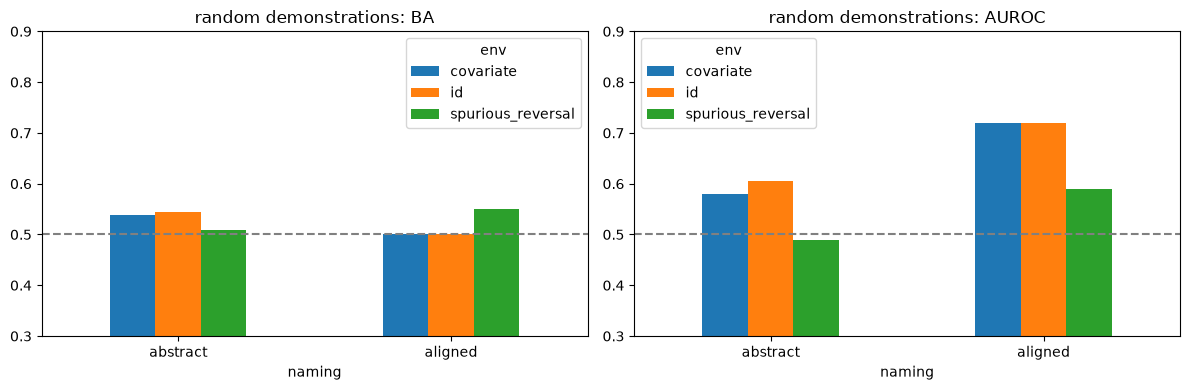

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, value in zip(axes, ("ba", "auroc")):
    t = summary_table(gold[gold.strategy == "random"], value, index=("naming",), columns=("env",))
    t.plot.bar(ax=ax, rot=0)
    ax.axhline(0.5, color="grey", ls="--"); ax.set_title(f"random demonstrations: {value.upper()}"); ax.set_ylim(0.3, 0.9)
plt.tight_layout()

## 2. RQ2: which strategy wins where?

Each strategy's BA minus label_diversity (random, balanced) on the same queries, by environment and naming.
Balanced strategies are compared with label_diversity, so label counts are held fixed.

In [4]:
t = summary_table(gold, "ba", index=("strategy",), columns=("naming", "env"))
display(t.round(3))
ref = t.loc["label_diversity"]
display((t - ref).drop(index="label_diversity").round(3))

naming            abstract                            aligned       \
env              covariate     id spurious_reversal covariate   id   
strategy                                                             
counter_spurious     0.533  0.524             0.528       NaN  NaN   
feature_range        0.531  0.533             0.499       NaN  NaN   
label_diversity      0.558  0.541             0.508       NaN  NaN   
random               0.538  0.544             0.508       0.5  0.5   
rule_diversity       0.547  0.545             0.503       NaN  NaN   
similarity           0.581  0.554             0.483       NaN  NaN   
zero_shot            0.533  0.490             0.481       0.6  0.6   

naming                              
env              spurious_reversal  
strategy                            
counter_spurious               NaN  
feature_range                  NaN  
label_diversity                NaN  
random                        0.55  
rule_diversity                 NaN  
similarity                     NaN  
zero_shot                     0.65

naming            abstract                            aligned      \
env              covariate     id spurious_reversal covariate  id   
strategy                                                            
counter_spurious    -0.026 -0.017             0.020       NaN NaN   
feature_range       -0.028 -0.008            -0.009       NaN NaN   
random              -0.020  0.003             0.001       NaN NaN   
rule_diversity      -0.011  0.004            -0.005       NaN NaN   
similarity           0.023  0.013            -0.024       NaN NaN   
zero_shot           -0.025 -0.051            -0.026       NaN NaN   

naming                              
env              spurious_reversal  
strategy                            
counter_spurious               NaN  
feature_range                  NaN  
random                         NaN  
rule_diversity                 NaN  
similarity                     NaN  
zero_shot                      NaN

In [5]:
t_auroc = summary_table(gold, "auroc", index=("strategy",), columns=("naming", "env"))
display((t_auroc - t_auroc.loc["label_diversity"]).drop(index="label_diversity").round(3))

naming            abstract                            aligned      \
env              covariate     id spurious_reversal covariate  id   
strategy                                                            
counter_spurious    -0.082 -0.030             0.032       NaN NaN   
feature_range       -0.083 -0.039            -0.023       NaN NaN   
random              -0.072  0.016            -0.031       NaN NaN   
rule_diversity      -0.025  0.040            -0.011       NaN NaN   
similarity          -0.031  0.036            -0.049       NaN NaN   
zero_shot           -0.122 -0.097            -0.026       NaN NaN   

naming                              
env              spurious_reversal  
strategy                            
counter_spurious               NaN  
feature_range                  NaN  
random                         NaN  
rule_diversity                 NaN  
similarity                     NaN  
zero_shot                      NaN

## 3. The spurious direction: prior-aligned and prior-opposed tasks

Qwen's numeric prior ("bigger values mean 1") backs f8's shortcut in tasks with σ_t = +1 and opposes it where σ_t = −1 (P2, `hiccups/09`).
Spurious reversal is therefore reported for each half separately, as the plan requires.

In [6]:
sr = gold[gold.env.isin(["id", "spurious_reversal"])]
t = (sr.groupby(["strategy", "naming", "spurious_direction", "env", "task_id"])["ba"].mean()
       .groupby(["strategy", "naming", "spurious_direction", "env"]).mean().unstack("env"))
t["gap"] = t["id"] - t["spurious_reversal"]
display(t.round(3))

env                                              id  spurious_reversal    gap
strategy         naming   spurious_direction                                 
counter_spurious abstract -1                  0.500              0.526 -0.026
                           1                  0.549              0.529  0.019
feature_range    abstract -1                  0.528              0.510  0.018
                           1                  0.538              0.488  0.050
label_diversity  abstract -1                  0.525              0.521  0.004
                           1                  0.557              0.494  0.062
random           abstract -1                  0.525              0.521  0.004
                           1                  0.564              0.496  0.068
                 aligned   1                  0.500              0.550 -0.050
rule_diversity   abstract -1                  0.536              0.508  0.028
                           1                  0.554              0.497  0.057
similarity       abstract -1                  0.588              0.462  0.125
                           1                  0.521              0.504  0.017
zero_shot        abstract -1                  0.408              0.513 -0.104
                           1                  0.571              0.450  0.121
                 aligned   1                  0.600              0.650 -0.050

## 4. Random-label control and prior agreement

- **Random-label control:** label_diversity with shuffled labels keeps the demonstrations' rows and label counts but breaks the input–label mapping. Gold minus shuffled is what the model takes from the mapping, under each naming.
- **Prior agreement:** the share of predictions equal to the model's zero-shot prediction under the same naming. High agreement means the demonstrations barely moved it.

In [7]:
ld = cells[cells.strategy == "label_diversity"]
if (ld.label_mode == "shuffled").any():
    t = (ld.groupby(["label_mode", "naming", "env", "task_id"])[["ba", "auroc"]].mean()
           .groupby(["label_mode", "naming", "env"]).mean().unstack("label_mode"))
    display(t.round(3))
else:
    print("the random-label control has not run yet")
pa = prior_agreement(grid)
display(pa[pa.label_mode == "gold"].groupby(["strategy", "naming"])["agree_raw"].mean().unstack("naming").round(3))

ba           auroc         
label_mode                   gold shuffled   gold shuffled
naming   env                                              
abstract covariate          0.558    0.512  0.652    0.558
         id                 0.541    0.501  0.589    0.523
         spurious_reversal  0.508    0.512  0.519    0.543

naming,abstract,aligned
strategy,,
counter_spurious,0.527,NaN
feature_range,0.536,NaN
label_diversity,0.547,NaN
random,0.541,0.75
rule_diversity,0.543,NaN
similarity,0.533,NaN


## 5. Why calibrated BA is not the test statistic

The share of cells in which calibration puts every query on one side of the threshold, by strategy and naming, and how far the content-free margin sits from the cell's median query margin.

In [8]:
from src.evaluation.analysis import prepare

g = prepare(grid[grid.strategy != "zero_shot"])
g["margin_cf"] = g["logprob_1_cf"] - g["logprob_0_cf"]
per_cell = (g.groupby(["strategy", "naming", "task_id", "seed", "env"])
              .apply(lambda c: pd.Series({"one_class": c["pred"].nunique() == 1,
                                          "cf_minus_median": c["margin_cf"].iloc[0] - c["margin"].median()}),
                     include_groups=False).reset_index())
display(per_cell.groupby(["strategy", "naming"])[["one_class", "cf_minus_median"]].mean().unstack("naming").round(3))

one_class         cf_minus_median        
naming            abstract aligned        abstract aligned
strategy                                                  
counter_spurious     0.190     NaN          -1.254     NaN
feature_range        0.162     NaN          -1.474     NaN
label_diversity      0.083     NaN          -2.126     NaN
random               0.319   0.667          -1.761  -7.579
rule_diversity       0.218     NaN          -1.767     NaN
similarity           0.014     NaN          -2.955     NaN

## 6. What the demonstration sets contain

Per strategy and naming, split by the task's spurious direction σ_t, the demonstration sets hold:
- the share of rows whose spurious feature agrees with their label (the shortcut's apparent reliability; the pool's rate is the task's strength, 0.80–0.90);
- the share labelled 1;
- the share of label-noise rows.

counter_prior picks rows on which the model's zero-shot answer is wrong.
With abstract names that answer mostly follows "bigger values mean 1", so where σ_t = −1 the wrong answers fall mainly on shortcut-agreeing rows.
This table shows whether counter_prior therefore reinforces the shortcut.

In [9]:
from src.data.suites import suite_dir
from src.data.synthetic_bridge import load_task_frame, pool_of

pools = {t: pool_of(load_task_frame(suite_dir("eval", config), t)) for t in grid.task_id.unique()}
units = grid[grid.label_mode == "gold"].drop_duplicates("unit_key")
units = units[units.strategy.isin(["random", "label_diversity", "feature_range", "rule_diversity",
                                   "counter_spurious", "counter_prior"])]
rows = []
for _, u in units.iterrows():
    d = pools[u.task_id].loc[list(u.demo_ids)]
    rows.append({"strategy": u.strategy, "naming": u.naming, "sigma": sigma[u.task_id],
                 "f8_agrees": d["agree_obs"].mean(), "label_1": d["label"].mean(),
                 "label_noise": (d["label"] != d["y_clean"]).mean()})
comp = pd.DataFrame(rows)
display(comp.groupby(["strategy", "naming", "sigma"])[["f8_agrees", "label_1", "label_noise"]].mean().unstack("sigma").round(3))

f8_agrees        label_1        label_noise       
sigma                            -1      1      -1      1          -1      1
strategy         naming                                                     
counter_spurious abstract     0.500  0.500   0.500  0.500       0.000  0.000
feature_range    abstract     0.670  0.653   0.500  0.500       0.097  0.062
label_diversity  abstract     0.837  0.837   0.500  0.500       0.021  0.017
random           abstract     0.844  0.844   0.517  0.490       0.031  0.028
                 aligned        NaN  0.875     NaN  0.625         NaN  0.000
rule_diversity   abstract     0.882  0.851   0.500  0.500       0.000  0.000

## 7. The contrast family (confirmatory)

Ten one-sided contrasts, Holm-adjusted together.
The RQ3 contrasts (C3a, C3b) come from `06_faithfulness_and_probes`; here they enter the family once `p4/rq3.parquet` exists.
A contrast whose conditions have not run yet is skipped, and the Holm adjustment then covers only the contrasts present, so it is final only when all ten are.

In [10]:
from src.evaluation.analysis import true_importance_by_column

rq3_path = RESULTS / "p4" / "rq3.parquet"
rq3 = pd.read_parquet(rq3_path) if rq3_path.exists() else None
available = []
for c in CONTRASTS:
    if c["kind"].startswith("rq3"):
        ok = rq3 is not None and {c["naming_a"], c["naming_b"]} <= set(rq3.naming)
    else:
        need_n = {c.get("naming"), c.get("naming_a"), c.get("naming_b")} - {None}
        need_s = {c.get("strategy"), c.get("a"), c.get("b")} - {None}
        ok = need_n <= set(grid.naming) and need_s <= set(grid.strategy)
    if ok:
        available.append(c)
res = run_contrasts(grid, rq3, true_importance_by_column(manifest), n_bootstrap=2000, contrasts=available)
print(f"{len(available)} of {len(CONTRASTS)} contrasts available")
with pd.option_context("display.max_colwidth", 80):
    display(res.round(4))
res.to_csv(RESULTS / "p4" / "contrasts.csv", index=False)

6 of 10 contrasts available


,id,rq,label,statistic,estimate,ci_low,ci_high,p_one_sided,tasks_in_direction,n_tasks,sign_test_p,ba_estimate,ba_ci,p_holm,significant
0,C1a,RQ1,"ID minus covariate, random demonstrations, abstract names",auroc,0.0257,-0.0445,0.0975,0.2339,15,24,0.1537,0.0063,"[-0.02986111111111112, 0.042378472222222144]",0.7016,False
1,C1b,RQ1,"ID minus spurious reversal, random demonstrations, abstract names",auroc,0.1171,0.0207,0.2190,0.0090,16,24,0.0758,0.0361,"[-0.004861111111111105, 0.0826562499999999]",0.0450,True
2,C2a,RQ2,counter_spurious minus label_diversity under spurious reversal,auroc,0.0321,-0.0185,0.0808,0.1134,16,24,0.0758,0.0201,"[-0.01666666666666667, 0.05555555555555557]",0.4538,False
3,C2b,RQ2,similarity (feature kNN) minus label_diversity under covariate shift,auroc,-0.0311,-0.1128,0.0454,0.7891,11,24,0.7294,0.0229,"[-0.03750000000000001, 0.07848958333333325]",1.0000,False
4,C2c,RQ2,feature_range minus label_diversity under covariate shift,auroc,-0.0826,-0.1476,-0.0231,0.9950,5,24,0.9987,-0.0278,"[-0.07362847222222223, 0.01666666666666666]",1.0000,False
5,C2e,RQ2,(counter_spurious minus label_diversity) under spurious reversal minus the s...,auroc,0.1139,0.0356,0.1949,0.0025,18,24,0.0113,0.0458,"[-0.009027777777777782, 0.10418402777777769]",0.0150,True
